<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Packages" data-toc-modified-id="Packages-0.1"><span class="toc-item-num">0.1&nbsp;&nbsp;</span>Packages</a></span></li><li><span><a href="#Load-palatals-csv" data-toc-modified-id="Load-palatals-csv-0.2"><span class="toc-item-num">0.2&nbsp;&nbsp;</span>Load palatals csv</a></span></li></ul></li><li><span><a href="#Frequencies" data-toc-modified-id="Frequencies-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Frequencies</a></span></li><li><span><a href="#Plot" data-toc-modified-id="Plot-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Plot</a></span></li></ul></div>

## Packages

In [1]:
import os
import re

import codecs
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

## Load palatals csv

In [2]:
entries_df = pd.read_csv('wikcionario_gl_pt_es_la-lh-nh_alt - latin.csv') 
entries_df

,gl,pt,es,la,gl_la,pt_la,es_la,notas,gl_la.1,pt_la.1,es_la.1
0,orella,orelha,oreja,auricula,cul,cul,NaN,NaN,cl,cl,NaN
1,ollo,olho,ojo,oculus,cul,cul,NaN,NaN,cl,cl,NaN
2,ventrullo,barriga,barriga,ventriculum,cul,NaN,NaN,NaN,cl,NaN,NaN
3,sobrecella,sobrancelha,ceja,supercilium,li,li,NaN,NaN,li,li,NaN
4,unlla,unha,uña,ungulam,ngul,ng,ng,NaN,ng,ng,ng
...,...,...,...,...,...,...,...,...,...,...,...
121,pulso,pulso,muñeca,pulsus,NaN,NaN,_,NaN,NaN,NaN,NaN
122,ano,ano,año,annus,NaN,NaN,nn,NaN,NaN,NaN,NaN
123,tinxir,tingir,teñir,tingere,NaN,NaN,ger,NaN,NaN,NaN,ger
124,constrinxir,constringir,constreñir,constringere,NaN,NaN,ger,NaN,NaN,NaN,ger


# Frequencies

In [9]:
gl_la_cat = pd.DataFrame()
gl_la_cat['counts'] = entries_df['gl_la'].value_counts()
gl_la_cat = gl_la_cat.reset_index()
gl_la_cat.columns = ['cat', 'gl_counts']
gl_la_cat['gl_counts'] = gl_la_cat.gl_counts/gl_la_cat["gl_counts"].sum()
gl_la_cat

,cat,gl_counts
0,in,0.189189
1,li,0.189189
2,cul,0.148649
3,ne,0.094595
4,ni,0.081081
5,?,0.054054
6,gn,0.054054
7,num,0.040541
8,le,0.027027
9,gul,0.013514


In [10]:
pt_la_cat = pd.DataFrame()
pt_la_cat['counts'] = entries_df['pt_la'].value_counts()
pt_la_cat = pt_la_cat.reset_index()
pt_la_cat.columns = ['cat', 'pt_counts']
pt_la_cat['pt_counts'] = pt_la_cat.pt_counts/pt_la_cat["pt_counts"].sum()
pt_la_cat

,cat,pt_counts
0,in,0.194805
1,li,0.181818
2,cul,0.116883
3,ne,0.077922
4,ni,0.064935
5,?,0.064935
6,gn,0.051948
7,_,0.038961
8,num,0.038961
9,le,0.025974


In [11]:
es_la_cat = pd.DataFrame()
es_la_cat['counts'] = entries_df['es_la'].value_counts()
es_la_cat = es_la_cat.reset_index()
es_la_cat.columns = ['cat', 'es_counts']
es_la_cat['es_counts'] = es_la_cat.es_counts/es_la_cat["es_counts"].sum()
es_la_cat

,cat,es_counts
0,ll,0.378788
1,_,0.106061
2,ne,0.090909
3,li,0.075758
4,ger,0.045455
5,^pl,0.045455
6,?,0.030303
7,l,0.030303
8,gn,0.030303
9,ni,0.030303


In [12]:
la_transform_df = pd.merge(gl_la_cat, pt_la_cat, how='outer', on='cat')
la_transform_df = pd.merge(la_transform_df, es_la_cat, how='outer', on='cat')

la_transform_df

,cat,gl_counts,pt_counts,es_counts
0,in,0.189189,0.194805,0.015152
1,li,0.189189,0.181818,0.075758
2,cul,0.148649,0.116883,NaN
3,ne,0.094595,0.077922,0.090909
4,ni,0.081081,0.064935,0.030303
5,?,0.054054,0.064935,0.030303
6,gn,0.054054,0.051948,0.030303
7,num,0.040541,0.038961,NaN
8,le,0.027027,0.025974,NaN
9,gul,0.013514,0.012987,NaN


In [13]:
la_transform_df = la_transform_df.set_index(["cat"])
la_transform_df

,gl_counts,pt_counts,es_counts
cat,,,
in,0.189189,0.194805,0.015152
li,0.189189,0.181818,0.075758
cul,0.148649,0.116883,NaN
ne,0.094595,0.077922,0.090909
ni,0.081081,0.064935,0.030303
?,0.054054,0.064935,0.030303
gn,0.054054,0.051948,0.030303
num,0.040541,0.038961,NaN
le,0.027027,0.025974,NaN


# Plot

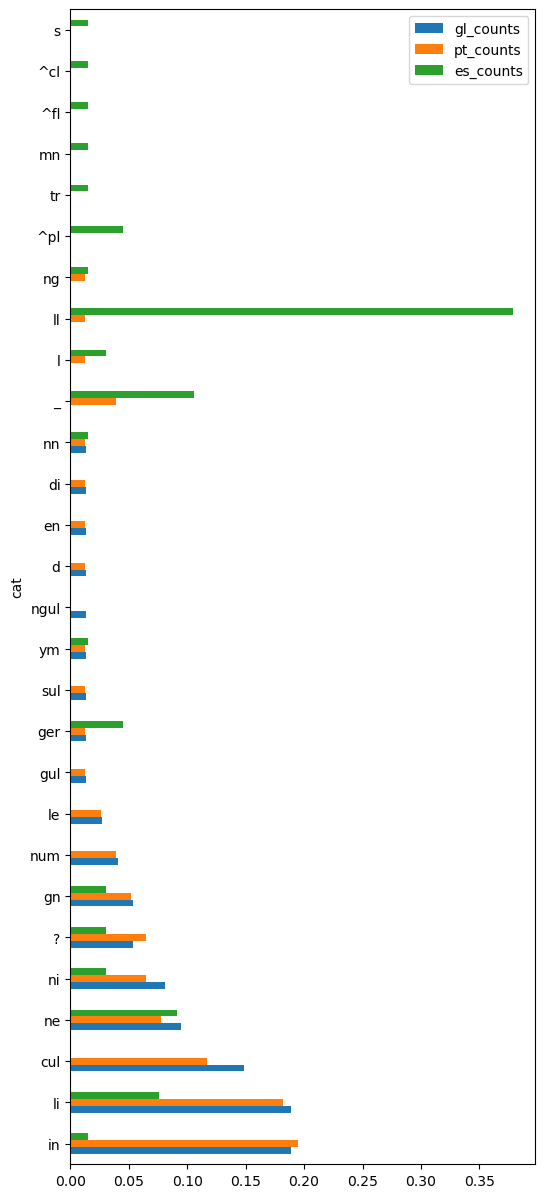

In [17]:
idx = la_transform_df.index.tolist()

la_transform_df.plot.barh(figsize=(6, 15))

plt.show()